In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [2]:
fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')

fd_df=fd_df.merge(PID_df[['PID','lat','lon', 'biome']], on='PID', how='left')

In [3]:
fd_df.drop_duplicates(subset=['PID'], inplace=True)


In [4]:
fd_df.columns

Index(['PID', 'Raos_Q', 'Functional_Evenness', 'Functional_Richness',
       'Species Richness', 'Shannon Diversity', 'Simpson's Index', 'WSCI',
       'Annual Temp', 'Annual Precipitation', 'Precipitation Seasonality',
       'Soil Moisture', 'SOC Content', 'Burnt Areas Probability', 'Elevation',
       'Slope', 'Depth to Bedrock', 'Northness', 'transformed npp',
       'treecover2000', 'pet_std', 'disturbance_value', 'land_cover_value',
       'lat', 'lon', 'biome'],
      dtype='str')

In [5]:
fd_df.dropna(subset=['Raos_Q', 'Functional_Evenness','Species Richness', 'Shannon Diversity',
       "Simpson's Index"], inplace=True)

In [6]:
fd_df['biome'].value_counts(dropna=False)

biome
Temperate broadleaf forests         32156
Temperate conifer forests           25904
Temperate grasslands                13985
Xeric shrublands                     4363
Tropical moist broadleaf forests      379
Tundra                                329
Boreal forests or taiga               324
Mediterranean woodlands               263
Tropical grasslands                   201
Tropical dry broadleaf forests        173
NaN                                   111
Tropical coniferous forests            85
Flooded grasslands                     51
Mangroves                              23
Name: count, dtype: int64

In [7]:
biome_mapping = {
    'Temperate broadleaf forests': 'Temperate broadleaf forests',
    'Temperate conifer forests': 'Temperate conifer forests',
    'Temperate grasslands': 'Temperate grasslands',
    'Xeric shrublands': 'Xeric shrublands',
    'Mediterranean woodlands': 'Mediterranean woodlands',
    'Flooded grasslands': 'Flooded grasslands',
    'Mangroves': 'Mangroves',
    'Tundra': 'Boreal and Tundra forests',
    'Boreal forests or taiga': 'Boreal and Tundra forests',
    'Tropical grasslands': 'Tropical',
    'Tropical coniferous forests': 'Tropical',
    'Tropical moist broadleaf forests': 'Tropical',
    'Tropical dry broadleaf forests': 'Tropical',
    np.nan: np.nan,  # Will be dropped
}
# Create a new column with readable biome names
fd_df['biome'] = fd_df['biome'].map(biome_mapping)


In [8]:

# Color map for ecoregions
biome_colors =  {
    'Temperate broadleaf forests': '#3CB371',      # Medium Sea Green
    'Temperate conifer forests': '#228B22',        # Forest Green
    'Temperate grasslands': '#DAA520',             # Goldenrod
    'Xeric shrublands': '#CD853F',                 # Peru - desert brown
    'Boreal and Tundra forests': '#4682B4',        # Steel Blue
    'Mediterranean woodlands': '#8FBC8F',          # Dark Sea Green
    'Tropical': '#00FF00',                         # Lime Green
    'Flooded grasslands': '#1E90FF',               # Dodger Blue
    'Mangroves': '#006400',                        # Dark Green
    'NaN': '#D3D3D3'
}

In [9]:

# Now create your map as before
fig = px.scatter_map(
    fd_df,
    lat="lat",
    lon="lon",
    color="biome",
    color_discrete_map=biome_colors,
    zoom=2,
    height=600
)

fig.update_traces(marker=dict(size=5, opacity=0.5))
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": "traces",
            "sourcetype": "raster",
            "sourceattribution": "Natural Earth",
            "source": [
                "https://basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}.png"
            ]
        }
    ],
    width=1500, 
    height=900,
    legend=dict(
        title=dict(text="Biome Type", font=dict(size=16)),
        font=dict(size=14),
        itemsizing='constant'
    )
)

fig.write_html("figures/map_by_biome.html", config={'responsive': False})

In [10]:

density_df = fd_df.groupby(['lat', 'lon', 'biome']).size().reset_index(name='density')

# Merge density back
fd_df = fd_df.merge(density_df, on=['lat', 'lon', 'biome'], how='left')

fig = px.scatter_geo(
    fd_df,
    lat='lat',
    lon='lon',
    color='biome',
    color_discrete_map=biome_colors,
    projection='natural earth',
    title='FD Distribution by Biome',
    hover_name='biome',
    hover_data={'transformed npp': ':.0f', 'lat': False, 'lon': False},
    # size_max=15  # <-- REMOVED: not needed without size
)

# Adjust marker size for points (not bubbles)
fig.update_traces(marker=dict(size=5, opacity=0.6))  # <-- Fixed point size

fig.update_geos(
    showcountries=True,
    countrycolor='gray',
    showcoastlines=True,
    coastlinecolor='gray',
    showland=True,
    landcolor='whitesmoke',
    showocean=True,
    oceancolor='lightcyan'
)

fig.update_layout(width=1400, height=800)
fig.write_html("figures/map_scattergeo_points.html")


In [11]:
density_df

,lat,lon,biome,density
0,-14.359294,-170.751111,Tropical,2
1,-14.321439,-170.770747,Tropical,1
2,-14.313557,-170.803711,Tropical,1
3,-14.309815,-170.801102,Tropical,1
4,-14.305973,-170.779482,Tropical,1
...,...,...,...,...
78081,65.329811,-146.189590,Boreal and Tundra forests,1
78082,65.346817,-148.534027,Boreal and Tundra forests,1
78083,65.374115,-149.122879,Boreal and Tundra forests,1
78084,65.443710,-148.541946,Boreal and Tundra forests,1


In [12]:


density_df = fd_df.groupby(['lat', 'lon', 'biome']).size().reset_index(name='density')

# Merge density back
# fd_df = fd_df.merge(density_df, on=['lat', 'lon', 'biome'], how='left')

fig = px.scatter_geo(
    density_df,
    lat='lat',
    lon='lon',
    color='biome',
    size='density',  # Bubble size = point density
    color_discrete_map=biome_colors,
    projection='natural earth',
    title='FD Distribution by Biome (Bubble size = point density)',
    hover_name='biome',
    hover_data={'density': ':.0f', 'lat': False, 'lon': False},
    size_max=15
)

fig.update_traces(marker=dict(opacity=0.6, sizemin=3))
fig.update_geos(
    showcountries=True,
    countrycolor='gray',
    showcoastlines=True,
    coastlinecolor='gray',
    showland=True,
    landcolor='whitesmoke',
    showocean=True,
    oceancolor='lightcyan'
)

fig.update_layout(width=1400, height=800)
fig.write_html("figures/map_scattergeo_density.html")

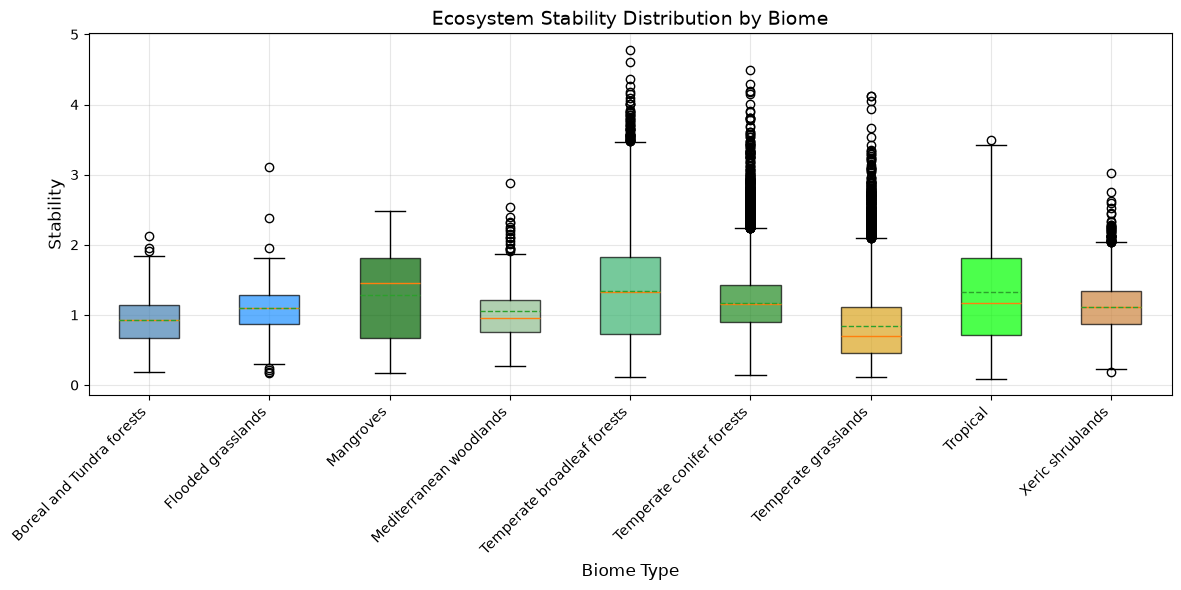

In [13]:
# Create boxplot
fig, ax = plt.subplots(figsize=(12, 6))


# Get biomes in order
biomes = fd_df['biome'].dropna().unique()
biomes = sorted(biomes)

# Create list of colors in same order
colors = [biome_colors[b] for b in biomes]

# Create boxplot
bp = ax.boxplot(
    [fd_df[fd_df['biome'] == b]['transformed npp'].dropna() for b in biomes],
    patch_artist=True,  # Fill boxes with color
    showmeans=True,
    meanline=True
)

# Color each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize plot
ax.set_xticklabels(biomes, rotation=45, ha='right')
ax.set_xlabel('Biome Type', fontsize=12)
ax.set_ylabel('Stability', fontsize=12)
ax.set_title('Ecosystem Stability Distribution by Biome', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/npp_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
fd_df['FD']= np.log(fd_df['Raos_Q'] + fd_df['Functional_Evenness'])
fd_df['SD']= np.log(fd_df['Shannon Diversity'] + fd_df["Simpson's Index"])

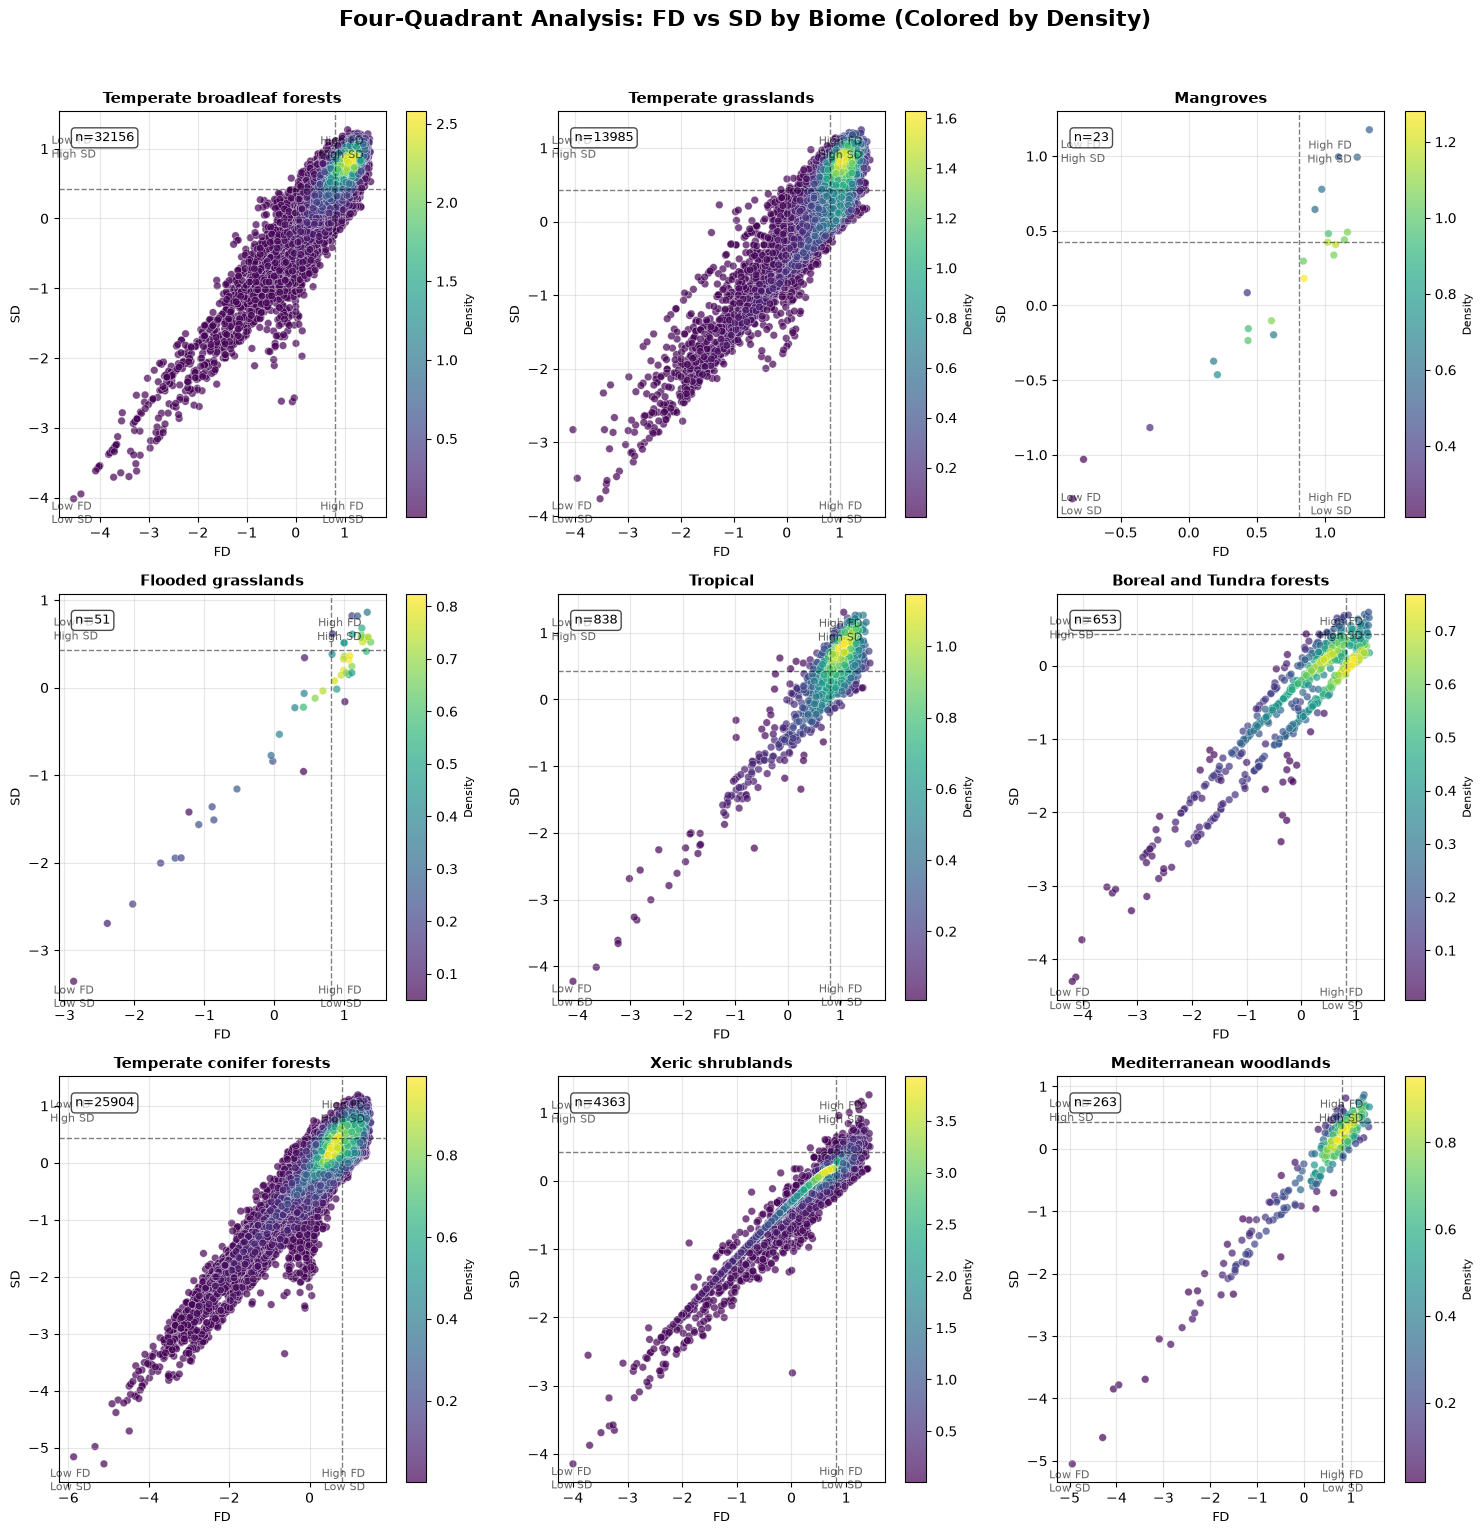

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# Calculate overall median thresholds for quadrants (consistent across biomes)
fd_median = fd_df['FD'].median()
sd_median = fd_df['SD'].median()

# Define quadrant function
def assign_quadrant(fd, sd, fd_thresh, sd_thresh):
    if fd >= fd_thresh and sd >= sd_thresh:
        return 'High FD, High SD'
    elif fd >= fd_thresh and sd < sd_thresh:
        return 'High FD, Low SD'
    elif fd < fd_thresh and sd >= sd_thresh:
        return 'Low FD, High SD'
    else:
        return 'Low FD, Low SD'

# Assign quadrants to all data
fd_df['quadrant'] = fd_df.apply(
    lambda row: assign_quadrant(row['FD'], row['SD'], fd_median, sd_median), 
    axis=1
)

# Get unique biomes
biomes = fd_df['biome'].dropna().unique()
n_biomes = len(biomes)
n_cols = min(3, n_biomes)
n_rows = (n_biomes + n_cols - 1) // n_cols

# Define quadrant colors (muted for background)
quadrant_colors = {
    'High FD, High SD': 'red',
    'High FD, Low SD': 'orange',
    'Low FD, High SD': 'blue',
    'Low FD, Low SD': 'gray'
}

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_biomes == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Function to calculate density for coloring
def get_density(x, y):
    """Calculate density for each point using KDE"""
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    return kde(xy)

for idx, biome in enumerate(biomes):
    ax = axes[idx]
    subset = fd_df[fd_df['biome'] == biome]
    
    if len(subset) >= 4:
        # Calculate density for coloring
        density = get_density(subset['FD'], subset['SD'])
        
        # Plot points colored by density
        scatter = ax.scatter(
            subset['FD'], 
            subset['SD'], 
            c=density, 
            cmap='viridis',
            alpha=0.7, 
            s=30,
            edgecolors='white',
            linewidth=0.3
        )
        
        # Add quadrant lines
        ax.axhline(y=sd_median, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.axvline(x=fd_median, color='black', linestyle='--', linewidth=1, alpha=0.5)
        
        # Add quadrant labels
        ax.text(subset['FD'].max() * 0.9, subset['SD'].max() * 0.95, 'High FD\nHigh SD', 
                ha='right', va='top', fontsize=8, alpha=0.6)
        ax.text(subset['FD'].min() * 1.1, subset['SD'].max() * 0.95, 'Low FD\nHigh SD', 
                ha='left', va='top', fontsize=8, alpha=0.6)
        ax.text(subset['FD'].max() * 0.9, subset['SD'].min() * 1.1, 'High FD\nLow SD', 
                ha='right', va='bottom', fontsize=8, alpha=0.6)
        ax.text(subset['FD'].min() * 1.1, subset['SD'].min() * 1.1, 'Low FD\nLow SD', 
                ha='left', va='bottom', fontsize=8, alpha=0.6)
        
        # Add statistics
        ax.text(0.05, 0.95, f'n={len(subset)}', transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        # Add colorbar for density
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Density', fontsize=8)
        
        ax.set_title(biome, fontsize=11, fontweight='bold')
        ax.set_xlabel('FD', fontsize=9)
        ax.set_ylabel('SD', fontsize=9)
        ax.grid(True, alpha=0.3)
        
    else:
        ax.text(0.5, 0.5, f'Insufficient data\nn={len(subset)}', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{biome}\nn={len(subset)}', fontsize=11)
        ax.set_xlabel('FD', fontsize=9)
        ax.set_ylabel('SD', fontsize=9)

# Remove empty subplots
for idx in range(len(biomes), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Four-Quadrant Analysis: FD vs SD by Biome (Colored by Density)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/quadrant_by_biome_density.png', dpi=300, bbox_inches='tight')
plt.show()

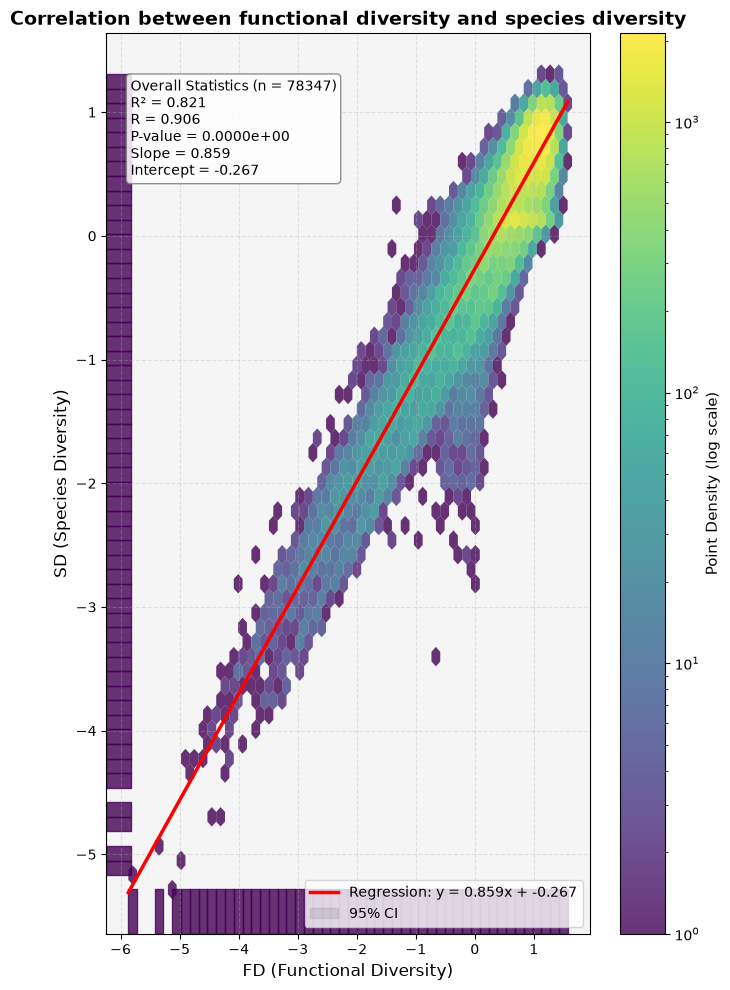

=== FD vs SD Linear Regression (Overall) ===
Sample size: 78347
R²: 0.8214
R: 0.9063
P-value: 0.0000e+00
Slope: 0.8592
Intercept: -0.2668
Standard error: 0.0014


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Create figure
fig, ax = plt.subplots(figsize=(7, 10))

# Prepare data
x = fd_df['FD']  # Functional Diversity
y = fd_df['SD']  # Species Diversity

# Create hexbin density heatmap
hb = ax.hexbin(
    x, y,
    gridsize=50,           # Number of hexagons
    cmap='viridis',        # Color scheme
    bins='log',            # Log scale for density
    alpha=0.8,
    mincnt=1,
    edgecolors='none',
    linewidths=0,
    marginals=True         # Show marginal distributions
)

# Add colorbar
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('Point Density (log scale)', fontsize=11)

# Calculate linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r2 = r_value**2

# Add regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', linewidth=2.5, 
        label=f'Regression: y = {slope:.3f}x + {intercept:.3f}')

# Add 95% confidence interval
n = len(x)
x_mean = np.mean(x)
x_var = np.sum((x - x_mean)**2)
se_pred = std_err * np.sqrt(1 + 1/n + (x_line - x_mean)**2 / x_var)
t_val = stats.t.ppf(0.975, n-2)
ci_upper = y_line + t_val * se_pred
ci_lower = y_line - t_val * se_pred
ax.fill_between(x_line, ci_lower, ci_upper, alpha=0.2, color='gray', label='95% CI')

# Add statistics text box
stats_text = f"Overall Statistics (n = {len(x)})\n"
stats_text += f"R² = {r2:.3f}\n"
stats_text += f"R = {r_value:.3f}\n"
stats_text += f"P-value = {p_value:.4e}\n"
stats_text += f"Slope = {slope:.3f}\n"
stats_text += f"Intercept = {intercept:.3f}"

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, 
                 edgecolor='gray'))

# Labels and title
ax.set_xlabel('FD (Functional Diversity)', fontsize=12)
ax.set_ylabel('SD (Species Diversity)', fontsize=12)
ax.set_title('Correlation between functional diversity and species diversity', 
             fontsize=14, fontweight='bold')

# Add legend and grid
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('whitesmoke')

plt.tight_layout()
plt.savefig('figures/fd_vs_sd_hexbin_regression_overall.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed results
print("=== FD vs SD Linear Regression (Overall) ===")
print(f"Sample size: {len(x)}")
print(f"R²: {r2:.4f}")
print(f"R: {r_value:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Standard error: {std_err:.4f}")

In [17]:
fd_df['biome']

0        Temperate broadleaf forests
1        Temperate broadleaf forests
2        Temperate broadleaf forests
3        Temperate broadleaf forests
4        Temperate broadleaf forests
                    ...             
78342    Temperate broadleaf forests
78343    Temperate broadleaf forests
78344    Temperate broadleaf forests
78345    Temperate broadleaf forests
78346    Temperate broadleaf forests
Name: biome, Length: 78347, dtype: str

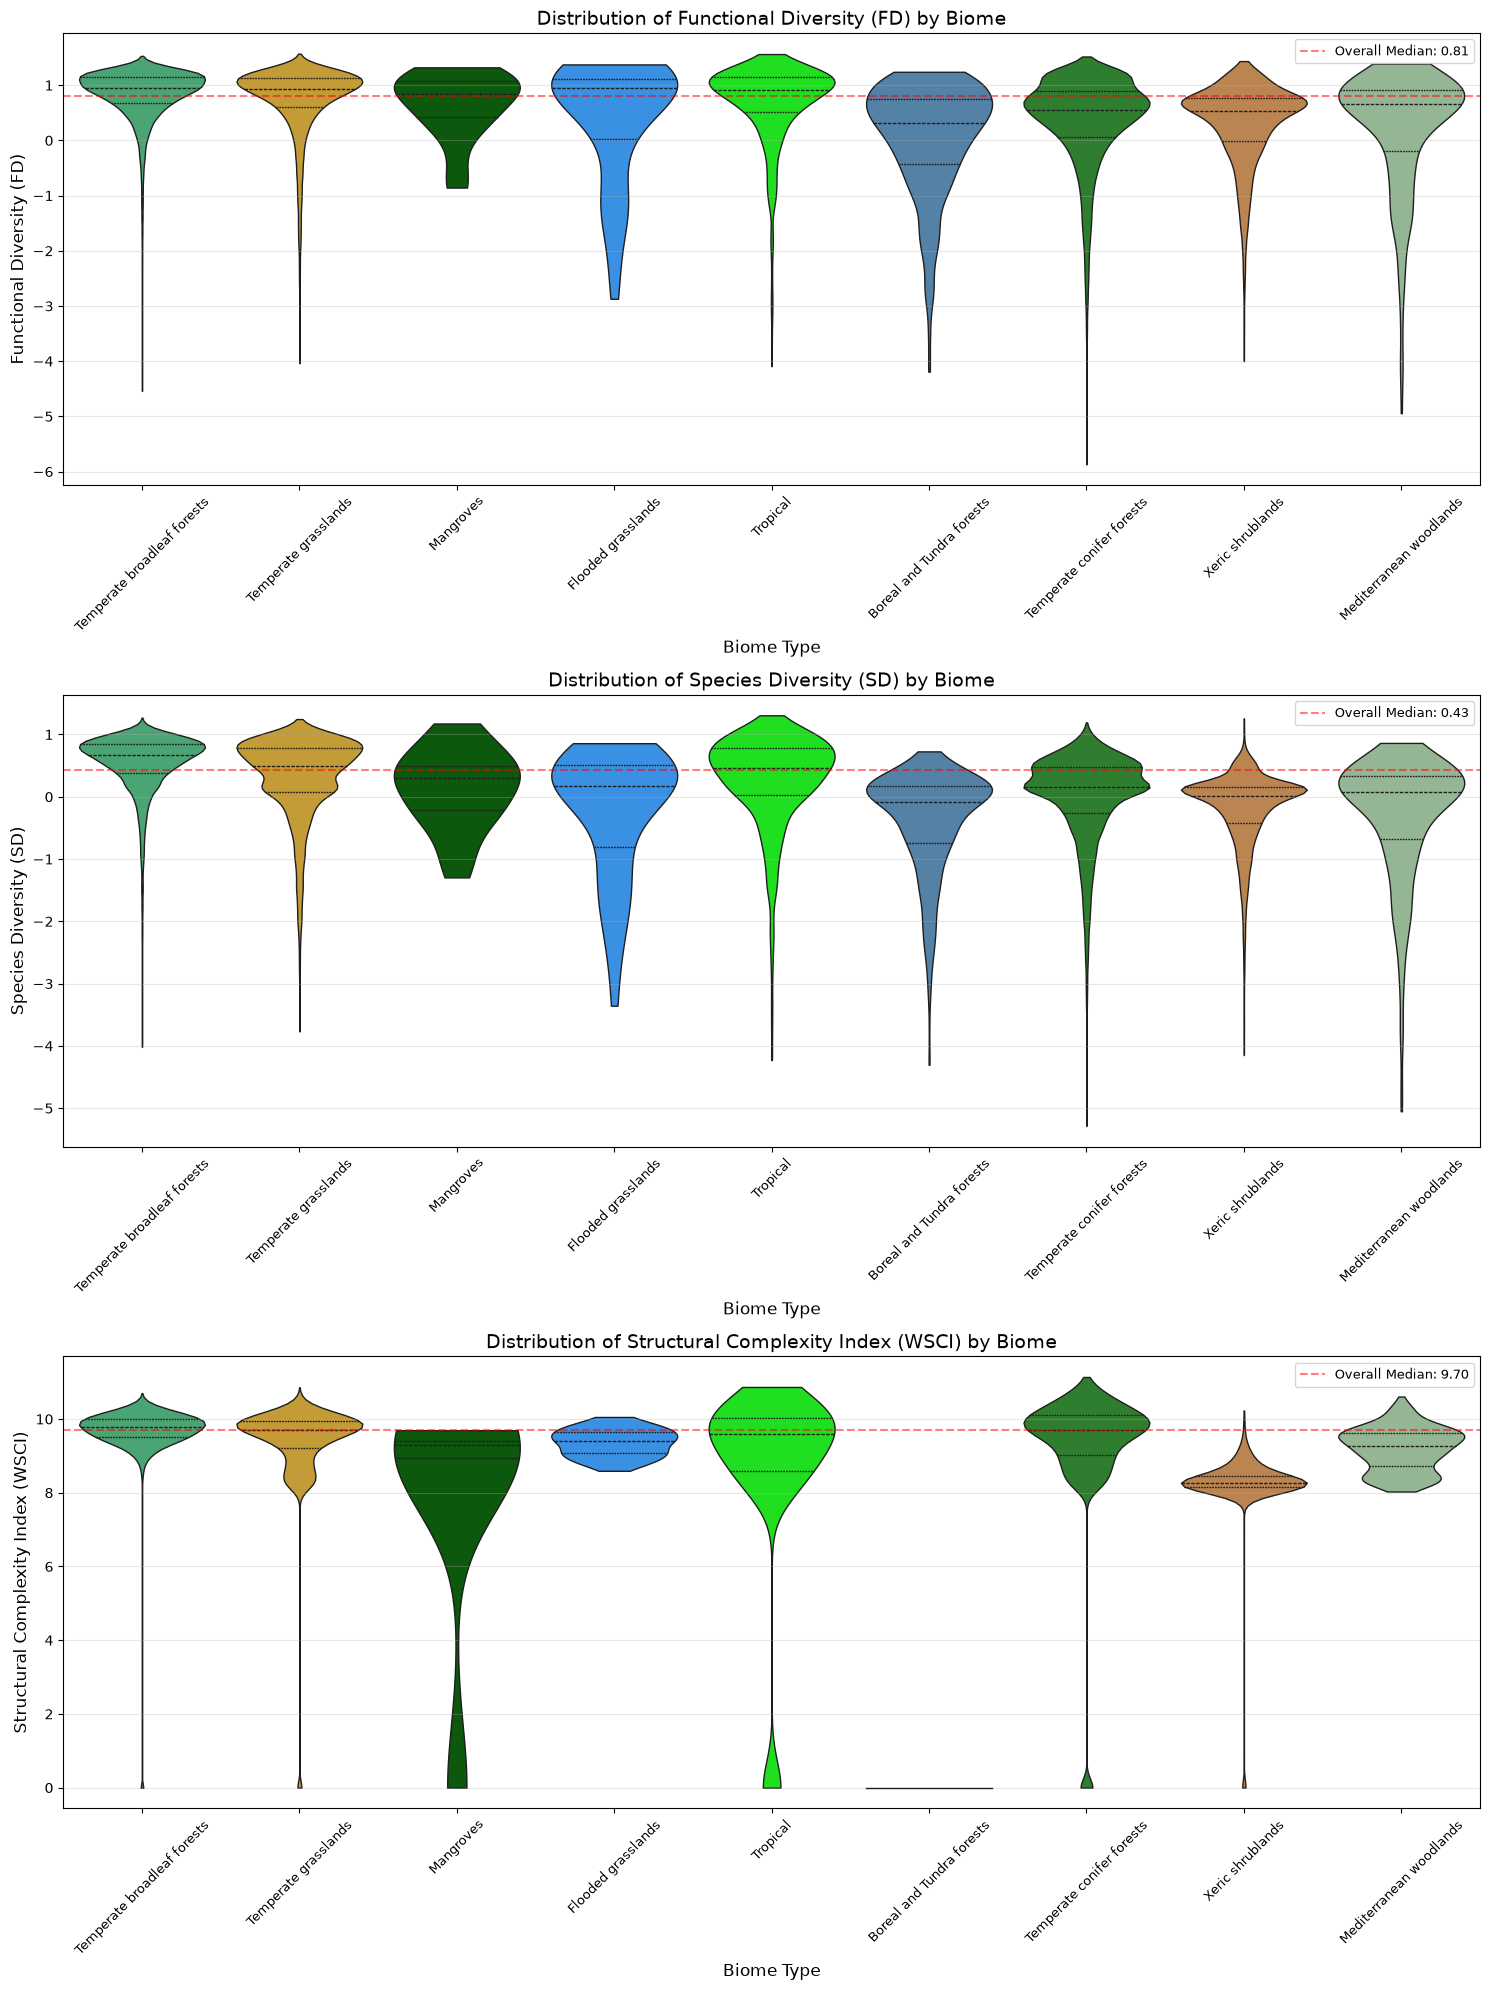

In [18]:
fd_df['biome'] = fd_df['biome']#.map(biome_mapping)
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

variables = ['FD', 'SD', "WSCI"]
variable_labels = ['Functional Diversity (FD)', 'Species Diversity (SD)', 'Structural Complexity Index (WSCI)']

for idx, (var, label) in enumerate(zip(variables, variable_labels)):
    ax = axes[idx]
    
    # Create violin plot - FIXED: assign hue and set legend=False
    sns.violinplot(
        data=fd_df,
        x='biome',
        y=var,
        hue='biome',  # <-- ADDED: assign x variable to hue
        palette=biome_colors,
        ax=ax,
        cut=0,
        inner='quartile',
        linewidth=1,
        legend=False  # <-- ADDED: prevent redundant legend
    )
    
    # Add median line for overall data
    overall_median = fd_df[var].median()
    ax.axhline(y=overall_median, color='red', linestyle='--', 
               linewidth=1.5, alpha=0.5, label=f'Overall Median: {overall_median:.2f}')
    
    ax.set_xlabel('Biome Type', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Distribution of {label} by Biome', fontsize=14)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/violin_plots_fd_sd_wsci.png', dpi=300, bbox_inches='tight')
plt.show()

Overall correlation FD vs WSCI: 0.082


/home/qli/Projects/env1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/qli/Projects/env1/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


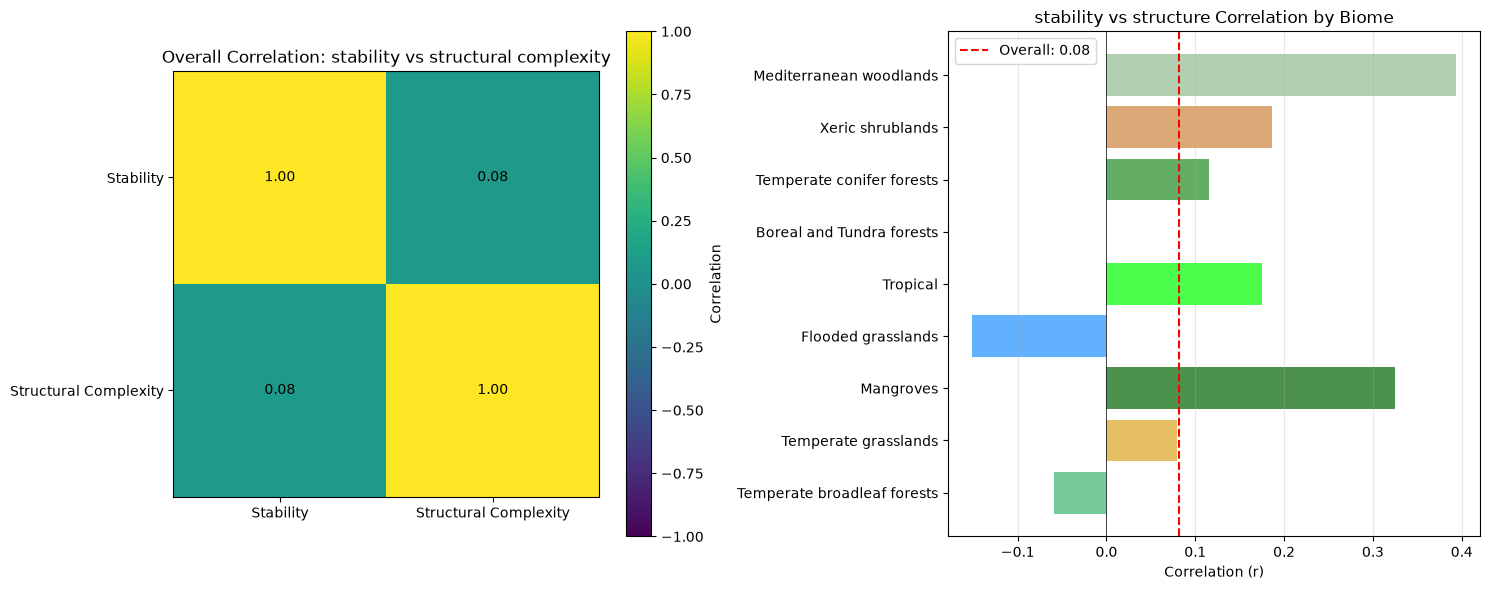

In [19]:
import seaborn as sns
import numpy as np
from scipy import stats

# Calculate overall correlation
overall_corr = fd_df['transformed npp'].corr(fd_df['WSCI'])
print(f"Overall correlation FD vs WSCI: {overall_corr:.3f}")

biomes=fd_df['biome'].dropna().unique()

# Calculate correlation matrix for all biomes combined
corr_matrix = fd_df[['transformed npp', 'WSCI']].corr()
corr_matrix.columns=['Stability', 'Structural Complexity']
# Also calculate per biome correlations for heatmap
biome_corr_matrix = pd.DataFrame(index=biomes, columns=['FD-WSCI Correlation'])
for biome_name in biomes:
    subset = fd_df[fd_df['biome'] == biome_name]
    if len(subset) > 1:
        biome_corr_matrix.loc[biome_name, 'FD-WSCI Correlation'] = subset['transformed npp'].corr(subset['WSCI'])
    else:
        biome_corr_matrix.loc[biome_name, 'FD-WSCI Correlation'] = np.nan

biome_corr_matrix['FD-WSCI Correlation'] = biome_corr_matrix['FD-WSCI Correlation'].astype(float)

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overall correlation heatmap
im1 = axes[0].imshow(corr_matrix.values, cmap='viridis', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_matrix.columns)))
axes[0].set_yticks(range(len(corr_matrix.columns)))
axes[0].set_xticklabels(corr_matrix.columns)
axes[0].set_yticklabels(corr_matrix.columns)
axes[0].set_title('Overall Correlation: stability vs structural complexity', fontsize=12)

# Add correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = axes[0].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                           ha="center", va="center", color="black")
plt.colorbar(im1, ax=axes[0], label='Correlation')

# Per-biome correlation bar plot
colors = [biome_colors.get(biome, 'gray') for biome in biome_corr_matrix.index]
bars = axes[1].barh(biome_corr_matrix.index, biome_corr_matrix['FD-WSCI Correlation'], 
                    color=colors, alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axvline(x=overall_corr, color='red', linestyle='--', 
                label=f'Overall: {overall_corr:.2f}')
axes[1].set_xlabel('Correlation (r)')
axes[1].set_title('stability vs structure Correlation by Biome')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/correlation_heatmap_fd_wsci.png', dpi=300, bbox_inches='tight')
plt.show()

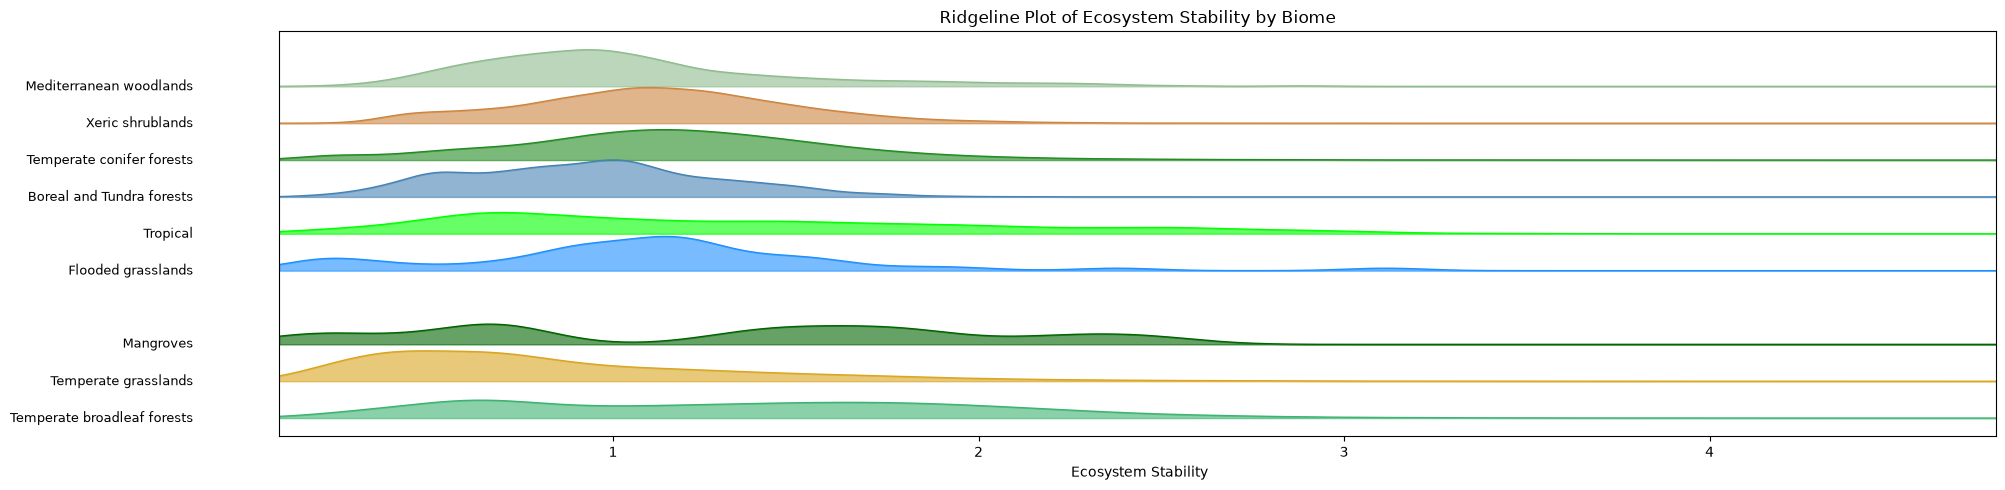

In [20]:
def ridgeline_plot(df, biome_colors, bandwidth=0.2, spacing=1.2):
    """
    Ridgeline plot of transformed NPP by biome.
    """

    biomes = (df["biome"].unique())

    # KDE grid
    x_min = df["transformed npp"].min()
    x_max = df["transformed npp"].max()
    x_grid = np.linspace(x_min, x_max, 300)

    fig, ax = plt.subplots(figsize=(20, 5))

    # give extra left margin for labels
    plt.subplots_adjust(left=0.2)

    for i, biome in enumerate(biomes):

        subset = df.loc[df["biome"] == biome, "transformed npp"].dropna().values

        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset, bw_method=bandwidth)
        y = kde(x_grid)

        y_offset = i * spacing
        color = biome_colors.get(biome, "gray")

        # ridge
        ax.fill_between(
            x_grid,
            y_offset,
            y + y_offset,
            color=color,
            alpha=0.6
        )
        ax.plot(x_grid, y + y_offset, color=color, linewidth=1)

        # 🧠 biome label OUTSIDE plot (left side)
        ax.text(
            x_min - 0.05 * (x_max - x_min),  # push left outside axis
            y_offset,
            biome,
            va="center",
            ha="right",
            fontsize=9,
            clip_on=False
        )

    # styling
    ax.set_yticks([])
    ax.set_xlabel(" Ecosystem Stability")
    ax.set_title("Ridgeline Plot of Ecosystem Stability by Biome")

    ax.set_xlim(x_min, x_max)

    plt.tight_layout()
    plt.show()


ridgeline_plot(fd_df, biome_colors)

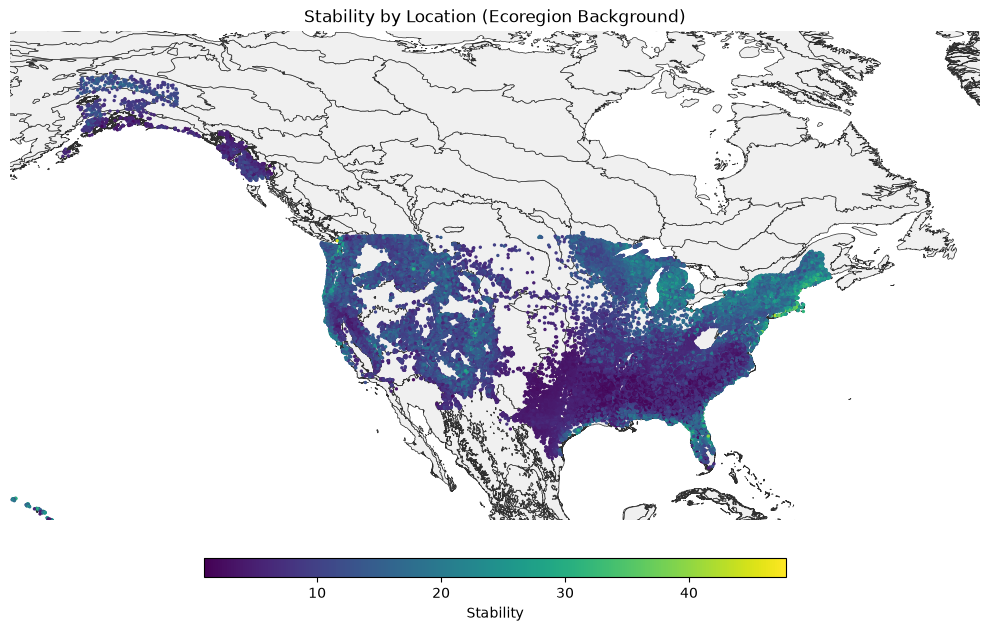

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load ecoregion polygons (shapefile/GeoJSON)
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")

fd_df['transformed npp'] = fd_df['transformed npp']*10

# Load your point data with a 'stability' column and geometry (or lat/lon)
points = gpd.GeoDataFrame(fd_df, geometry=gpd.points_from_xy(fd_df.lon, fd_df.lat), crs="EPSG:4326")

# Make sure both layers are in the same CRS (reproject points if needed)
if ecoregions.crs != points.crs:
    points = points.to_crs(ecoregions.crs)

fig, ax = plt.subplots(figsize=(10, 8))

# Ecoregion background — light neutral fill, distinguishable by boundary
ecoregions.plot(ax=ax, color='#f0f0f0', edgecolor="#2E2E2E", linewidth=0.5)

# Stability as colormap on top, with a horizontal colorbar placed at the bottom
points.plot(
    ax=ax,
    column='transformed npp',
    cmap='viridis',
    markersize=2,
    legend=True,
    legend_kwds={
        'label': "Stability",
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.05,       # space between map and colorbar
        'aspect': 30       # makes the bar thinner/longer
    }
)

# Zoom to North America (roughly: lon -170 to -50, lat 5 to 75)
ax.set_xlim(-160, -50)
ax.set_ylim(20, 70)

ax.set_title("Stability by Location (Ecoregion Background)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load ecoregion polygons (shapefile/GeoJSON)
ecoregions = gpd.read_file("data/Ecoregions/Ecoregions2017.shp")

fd_df['WSCI'] = fd_df['WSCI']*10

# Load your point data with a 'stability' column and geometry (or lat/lon)
points = gpd.GeoDataFrame(fd_df, geometry=gpd.points_from_xy(fd_df.lon, fd_df.lat), crs="EPSG:4326")

# Make sure both layers are in the same CRS (reproject points if needed)
if ecoregions.crs != points.crs:
    points = points.to_crs(ecoregions.crs)

fig, ax = plt.subplots(figsize=(10, 8))

# Ecoregion background — light neutral fill, distinguishable by boundary
ecoregions.plot(ax=ax, color='#f0f0f0', edgecolor="#2E2E2E", linewidth=0.5)

# Stability as colormap on top, with a horizontal colorbar placed at the bottom
points.plot(
    ax=ax,
    column='WSCI',
    cmap='PRGn',
    markersize=2,
    legend=True,
)



# Zoom to North America (roughly: lon -170 to -50, lat 5 to 75)
ax.set_xlim(-160, -50)
ax.set_ylim(20, 70)

ax.set_title("Stability by Location (Ecoregion Background)")
ax.set_axis_off()
plt.tight_layout()
plt.show()